In [1]:
import findspark
findspark.init()

In [2]:
test_data_no_loc = "../Datasets/Brain_Tumor_Datasets/test/no"
test_data_yes_loc = "../Datasets/Brain_Tumor_Datasets/test/yes"
train_data_no_loc = "../Datasets/Brain_Tumor_Datasets/train/no"
train_data_yes_loc = "../Datasets/Brain_Tumor_Datasets/train/yes"


In [3]:
from PIL import Image
import numpy as np
import pandas as pd
import os

def preprocess_images_from_dir(directory, label, size=(64, 64)):
    data = []
    for fname in os.listdir(directory):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            try:
                img = Image.open(os.path.join(directory, fname)).convert('L').resize(size)
                arr = np.array(img).flatten() / 255.0  # normalize
                data.append((arr.tolist(), label))
            except Exception as e:
                print(f"Failed on {fname}: {e}")
    return pd.DataFrame(data, columns=['features', 'label'])


In [4]:
test_no_df = preprocess_images_from_dir(test_data_no_loc, label=0)
test_yes_df = preprocess_images_from_dir(test_data_yes_loc, label=1)
train_no_df = preprocess_images_from_dir(train_data_no_loc, label=0)
train_yes_df = preprocess_images_from_dir(train_data_yes_loc, label=1)

In [5]:
full_df = pd.concat([test_no_df, test_yes_df, train_no_df, train_yes_df], ignore_index=True)

In [6]:
print(full_df['label'].value_counts())


label
1    5178
0    3586
Name: count, dtype: int64


<ipython-input-7-8b5a3a7712a6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = full_df, x = 'label', palette = 'coolwarm')


<Axes: xlabel='label', ylabel='count'>

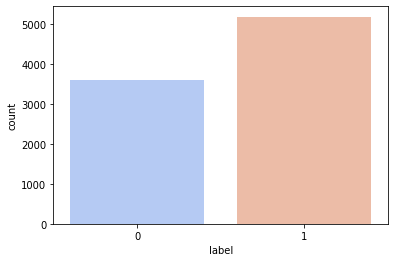

In [7]:
import seaborn as sns
sns.countplot(data = full_df, x = 'label', palette = 'coolwarm')

In [8]:
full_df.head()

,features,label
0,"[0.0, 0.0, 0.0, 0.0, 0.00784313725490196, 0.00...",0
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
3,"[0.00392156862745098, 0.00392156862745098, 0.0...",0
4,"[0.10980392156862745, 0.10980392156862745, 0.1...",0


In [9]:
from sklearn.decomposition import PCA

# Assume full_df has 'features' as a list of floats and 'label'
X = np.stack(full_df['features'].to_numpy())  # shape: (n_samples, n_features)

pca = PCA(n_components=100, random_state=42)
X_reduced = pca.fit_transform(X)

# Replace features column with reduced PCA vectors
full_df["features"] = [list(row) for row in X_reduced]
print(len(full_df["features"].iloc[0]))


100


In [30]:
#download PCA pickle
import pickle


# Replace 'pca' with your actual trained PCA model variable
with open("images_pca_model.pkl", "wb") as f:
    pickle.dump(pca, f)



In [10]:
from pyspark.sql import SparkSession, Row


In [11]:
from pyspark.ml.linalg import Vectors
import pandas as pd

#Dense Vector creation
full_df["features"] = full_df["features"].map(lambda x: Vectors.dense(x))


In [12]:
full_df.head()

,features,label
0,"[-4.533333829880326, 0.1250200245220996, -1.48...",0
1,"[-0.34246321775434485, -5.659547454842711, 1.1...",0
2,"[-4.370032538077476, -2.094575598241832, 1.888...",0
3,"[4.852335353334105, 4.540053836611714, -0.1446...",0
4,"[12.067305007625482, -7.595110732194349, 0.689...",0


In [13]:
print(type(full_df.iloc[0]["features"]))


<class 'pyspark.ml.linalg.DenseVector'>


In [14]:
spark = SparkSession.builder.appName("image_pipeline").getOrCreate()

rows = [Row(features=row['features'], label=int(row['label'])) for _, row in full_df.iterrows()]
spark_df = spark.createDataFrame(rows)

spark_df.printSchema()
spark_df.show(1)

root
 |-- features: vector (nullable = true)
 |-- label: long (nullable = true)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[-4.5333338298803...|    0|
+--------------------+-----+
only showing top 1 row



# Training and testing for modeling/ balancing

In [15]:
train_df, test_df = spark_df.randomSplit([0.7, 0.3], seed=101)


In [16]:
train_df.cache()
train_df.show(1)
minority_count = train_df.filter("label = 1").count()
majority_count = train_df.filter("label = 0").count()

print(f"Label 0 count: {majority_count}")
print(f"Label 1 count: {minority_count}")

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[-10.419064001375...|    0|
+--------------------+-----+
only showing top 1 row

Label 0 count: 2463
Label 1 count: 3584


In [17]:
from pyspark.sql.functions import rand

if minority_count < majority_count:
    train_majority = train_df.filter("label = 0").orderBy(rand()).limit(minority_count)
    train_minority = train_df.filter("label = 1")
else:
    train_majority = train_df.filter("label = 1").orderBy(rand()).limit(majority_count)
    train_minority = train_df.filter("label = 0")

In [18]:
balanced_train_df = train_majority.union(train_minority)
print(f" Balanced training set size: {balanced_train_df.count()}")
balanced_train_df.groupBy("label").count().show()

 Balanced training set size: 4926
+-----+-----+
|label|count|
+-----+-----+
|    1| 2463|
|    0| 2463|
+-----+-----+



In [19]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)
lr_model = lr.fit(train_df)
predictions = lr_model.transform(test_df)
predictions.show(5)


+--------------------+-----+--------------------+--------------------+----------+
|            features|label|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+----------+
|[-9.2061606241238...|    0|[-1.2175376928813...|[0.22837006114731...|       1.0|
|[-9.2061606241238...|    0|[-1.2175376928813...|[0.22837006114731...|       1.0|
|[-8.4676873769247...|    1|[-3.1826914056297...|[0.03982229651977...|       1.0|
|[-8.3827202479696...|    1|[-2.4910953719428...|[0.07648478999838...|       1.0|
|[-8.1114954042914...|    0|[3.71172280959568...|[0.97614745672038...|       0.0|
+--------------------+-----+--------------------+--------------------+----------+
only showing top 5 rows



In [20]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
#Basic linear regression model for base model

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
predictions.show(5)
accuracy = evaluator.evaluate(predictions)
print(f" Logistic Regression f1: {accuracy:.4f}")

+--------------------+-----+--------------------+--------------------+----------+
|            features|label|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+----------+
|[-9.2061606241238...|    0|[-1.2175376928813...|[0.22837006114731...|       1.0|
|[-9.2061606241238...|    0|[-1.2175376928813...|[0.22837006114731...|       1.0|
|[-8.4676873769247...|    1|[-3.1826914056297...|[0.03982229651977...|       1.0|
|[-8.3827202479696...|    1|[-2.4910953719428...|[0.07648478999838...|       1.0|
|[-8.1114954042914...|    0|[3.71172280959568...|[0.97614745672038...|       0.0|
+--------------------+-----+--------------------+--------------------+----------+
only showing top 5 rows

 Logistic Regression f1: 0.9003


In [21]:
#base decision tree for baseline 
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
dt_model = dt.fit(train_df)
predictions2 = dt_model.transform(test_df)
predictions.show(5)


+--------------------+-----+--------------------+--------------------+----------+
|            features|label|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+----------+
|[-9.2061606241238...|    0|[-1.2175376928813...|[0.22837006114731...|       1.0|
|[-9.2061606241238...|    0|[-1.2175376928813...|[0.22837006114731...|       1.0|
|[-8.4676873769247...|    1|[-3.1826914056297...|[0.03982229651977...|       1.0|
|[-8.3827202479696...|    1|[-2.4910953719428...|[0.07648478999838...|       1.0|
|[-8.1114954042914...|    0|[3.71172280959568...|[0.97614745672038...|       0.0|
+--------------------+-----+--------------------+--------------------+----------+
only showing top 5 rows



In [22]:

evaluator2 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
accuracy2 = evaluator2.evaluate(predictions2)
print(f" Decision Tree f1: {accuracy2:.4f}")


 Decision Tree f1: 0.8853


In [23]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=25, maxDepth = 20)
rf_model = rf.fit(train_df)

rf_preds = rf_model.transform(test_df)


In [24]:
from pyspark.ml.classification import GBTClassifier

# GBT only supports label type Double (not Long)
train_df_gbt = train_df.withColumn("label", train_df["label"].cast("double"))
test_df_gbt = test_df.withColumn("label", test_df["label"].cast("double"))

gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=25, maxDepth = 20)
gbt_model = gbt.fit(train_df_gbt)

gbt_preds = gbt_model.transform(test_df_gbt)


In [25]:

rf_acc = evaluator.evaluate(rf_preds)
gbt_acc = evaluator.evaluate(gbt_preds)

print(f" Random Forest f1: {rf_acc:.4f}")
print(f" GBT f1: {gbt_acc:.4f}")

 Random Forest f1: 0.9749
 GBT f1: 0.9603


In [26]:
#tuning for random forest as that was the best model 
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=101)

paramGrid = ParamGridBuilder() \
    .addGrid(rf.maxDepth, [20, 25, 30]) \
    .addGrid(rf.numTrees, [50, 100, 150]) \
    .build()
cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2  
)

cv_model = cv.fit(train_df)

# Best model and its F1
rf_best_model = cv_model.bestModel
rf_preds = rf_best_model.transform(test_df)
rf_f1 = evaluator.evaluate(rf_preds)
print(f"Tuned RF F1 Score: {rf_f1:.4f}")



Tuned RF F1 Score: 0.9749


In [27]:
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="precisionByLabel")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="recallByLabel")

precision = evaluator_precision.evaluate(rf_preds)
recall = evaluator_recall.evaluate(rf_preds)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.975653742110009
Recall: 0.9634906500445236


In [28]:
print(rf_best_model.extractParamMap())


{Param(parent='RandomForestClassifier_d921f1f225ff', name='bootstrap', doc='Whether bootstrap samples are used when building trees.'): True, Param(parent='RandomForestClassifier_d921f1f225ff', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False, Param(parent='RandomForestClassifier_d921f1f225ff', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext.'): 10, Param(parent='RandomForestClassifier_d921f1f225ff', name='featureSubsetStrategy', doc="The number of features to consider for splits at each tree node. Support

In [31]:
rf_best_model.write().overwrite().save("hdfs://localhost:9000/user/jj/final_proj/images_rf_model")

In [34]:
rf_preds.select('probability').show(1, truncate = False)

+----------------------------------------+
|probability                             |
+----------------------------------------+
|[0.06008088978766431,0.9399191102123357]|
+----------------------------------------+
only showing top 1 row



In [35]:
rf_preds.show(1)

+--------------------+-----+--------------------+--------------------+----------+
|            features|label|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+----------+
|[-9.2061606241238...|    0|[3.00404448938321...|[0.06008088978766...|       1.0|
+--------------------+-----+--------------------+--------------------+----------+
only showing top 1 row

